In [1]:
# Set working directory
import os
os.chdir("../../")

In [2]:
# Configure file paths

# Motif binding score directory (see analysis code for calculation)
binding_data_path = "binding_score_at_motifs"

## Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FixedFormatter

## Load motif binding data

In [4]:
SOX = ["SOX6", "SOX5", "SOX13", "SOX17"]

In [5]:
df_dict = {}
for sample in SOX:
    df_dict[sample] = pd.read_csv(f'{binding_data_path}/{sample}/{sample}__orig-human__loc-prom__motif-SOX10.H12CORE.1.PSM.A__type-family__fl25__nuc-7-25-50__trim150.csv')

## Plots

In [6]:
def plot_pairwise_start_diffs(dfs_dict, SOX, visual_window, bin_width):

    keys = [k for k in SOX if k in dfs_dict]
    n = len(keys)
    if n == 0:
        return

    ncols = 4
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(3 * ncols, 3.2 * nrows),
        squeeze=False
    )
    axes = axes.ravel()

    y_ticks = [-1, 0, 1, 3, 10, 100]

    bins = np.arange(0, visual_window + bin_width, bin_width)

    for ax_i, k in enumerate(keys):
        ax = axes[ax_i]

        df = dfs_dict[k][["sequence_name", "start", "z_score_norm_f7"]].copy()
        df = df.dropna(subset=["sequence_name", "start", "z_score_norm_f7"])
        df = df[df["sequence_name"].map(df["sequence_name"].value_counts()) > 1]

        xs, ys = [], []

        for seq, g in df.groupby("sequence_name"):
            s = g["start"].to_numpy()
            z = g["z_score_norm_f7"].to_numpy()

            for i in range(len(g)):
                for j in range(i + 1, len(g)):
                    d = abs(s[j] - s[i])
                    if d <= visual_window:
                        xs.extend([d, d])
                        ys.extend([z[i], z[j]])

        plot_df = pd.DataFrame({
            "distance": xs,
            "z_score_norm_f7": ys
        })

        if plot_df.empty:
            continue

        plot_df["bin"] = pd.cut(plot_df["distance"], bins=bins)

        grouped = plot_df.groupby("bin")["z_score_norm_f7"]

        data = []
        positions = []
        xtick_labels = []

        for b in grouped.groups:
            data.append(grouped.get_group(b))
            positions.append(b.right)                 # use bin max
            xtick_labels.append(f"{b.right:.0f}")    # 0 decimals

        bp = ax.boxplot(
            data,
            positions=positions,
            widths=bin_width * 0.8,
            patch_artist=True
        )

        # style boxes
        for box in bp["boxes"]:
            box.set(facecolor="#8FB6FF")

        for median in bp["medians"]:
            median.set(color="black")

        ax.set_xticks(positions)
        ax.set_xticklabels(xtick_labels)

        ax.axhline(3, linestyle="--", linewidth=1, alpha=0.55, color="gray")

        ax.set_title(k, fontsize=14)
        ax.set_xlabel("Distance between motifs (bp)", fontsize=12)
        ax.set_ylabel("z-score", labelpad=-4, fontsize=12)

        ax.set_yscale("symlog", linthresh=3)
        ax.set_ylim(-1.4, 200)
        ax.yaxis.set_major_locator(FixedLocator(y_ticks))
        ax.yaxis.set_major_formatter(FixedFormatter([str(t) for t in y_ticks]))

    for j in range(n, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_1522915/1097082519.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = plot_df.groupby("bin")["z_score_norm_f7"]
/tmp/ipykernel_1522915/1097082519.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = plot_df.groupby("bin")["z_score_norm_f7"]
/tmp/ipykernel_1522915/1097082519.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = plot_df.groupby("bin")["z_score_norm_f7"]
/tmp/ip

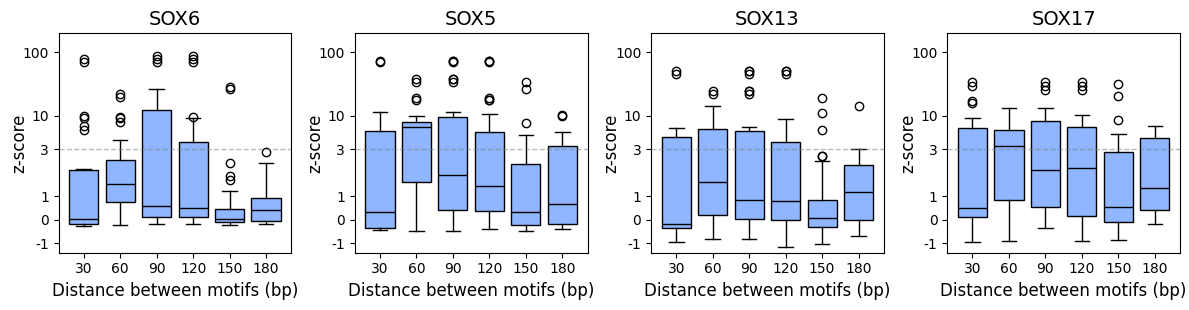

In [7]:
plot_pairwise_start_diffs(df_dict, SOX, visual_window=180, bin_width=30)

In [8]:
def plot_bound_same_strand_neighbor_fraction(dfs_dict, samples, z_thr=3, window=50):
    keys = [k for k in samples if k in dfs_dict]
    if not keys: return

    rows = []
    for k in keys:
        df = dfs_dict[k][["sequence_name","start","strand","z_score_norm_f7"]].dropna()
        bound = df[df["z_score_norm_f7"] > z_thr].copy()
        N = len(bound)

        if N == 0:
            rows.append({"sample":k,"double_%":0,"single_%":0,"N_double":0,"N_single":0})
            continue

        bound["has_neighbor"] = False
        for (_, _), g in bound.groupby(["sequence_name","strand"]):
            g = g.sort_values("start")
            s = g["start"].to_numpy()
            close = np.r_[False,(s[1:]-s[:-1])<=window] | np.r_[(s[1:]-s[:-1])<=window,False]
            bound.loc[g.index,"has_neighbor"] = close

        N_double = int(bound["has_neighbor"].sum())
        N_single = N - N_double
        rows.append({
            "sample":k,
            "double_%":100*N_double/N,
            "single_%":100*N_single/N,
            "N_double":N_double,
            "N_single":N_single
        })

    res = pd.DataFrame(rows)
    x = np.arange(len(res))
    fig, ax = plt.subplots(figsize=(10,4.5))

    c_double, c_single, w = "#0B3D91", "#8FB6FF", 0.55
    ax.bar(x, res["double_%"], width=w, color=c_double, edgecolor="white", linewidth=0.8,
           label=f"Proximal motif (≤{window} bp)")
    ax.bar(x, res["single_%"], bottom=res["double_%"], width=w, color=c_single,
           edgecolor="white", linewidth=0.8, label="Isolated motif (>30 bp)")

    for i,r in res.iterrows():
        d_pct, s_pct = r["double_%"], r["single_%"]
        txt_double = f'{int(r["N_double"])} ({d_pct:.0f}%)'
        txt_single = f'{int(r["N_single"])}\n({s_pct:.0f}%)'

        if d_pct > 0:
            ax.text(i, d_pct/2, txt_double, ha="center", va="center",
                    fontsize=9, color="white")
        else:
            ax.text(i, 2, txt_double, ha="center", va="bottom",
                    fontsize=9, color=c_double)

        ax.text(i, 75, txt_single, ha="center", va="center",
                fontsize=9, color=c_double)

    ax.set_xticks(x)
    ax.set_xticklabels(res["sample"], rotation=45, ha="right", fontsize=12)
    ax.set_ylabel("Percent of bound motifs (%)", fontsize=13)
    ax.set_ylim(0,100)
    ax.tick_params(axis="y", labelsize=12)

    ax.legend(loc="center left", bbox_to_anchor=(1.02,0.5), frameon=False, fontsize=11)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()
    return res

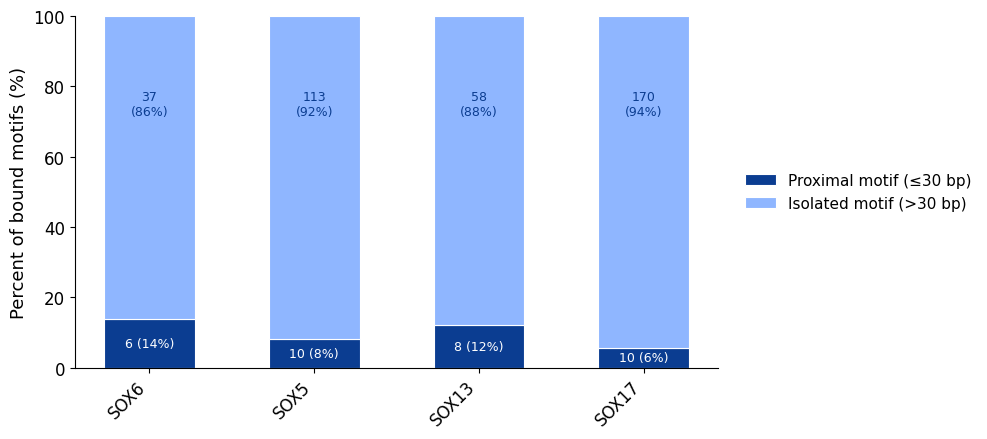

,sample,double_%,single_%,N_double,N_single
0,SOX6,13.953488,86.046512,6,37
1,SOX5,8.130081,91.869919,10,113
2,SOX13,12.121212,87.878788,8,58
3,SOX17,5.555556,94.444444,10,170


In [9]:
plot_bound_same_strand_neighbor_fraction(df_dict, SOX, z_thr=3, window=30)